In [43]:
import torch
import numpy as np
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable
%config InlineBackend.figure_format = 'retina'
plt.rcParams['text.usetex'] = True

from src.metrics.alignment.soft_match import SoftMatch
from src.metrics.alignment.partial_wasserstein import UnbalancedSoftMatch
from src.utils.synthesize import generate_neural_representations, concat_noisy_neurons

In [36]:
# instantiate metric objects
# unbalanced soft-matching
unbalanced_sm = UnbalancedSoftMatch(mass_reg=100/190)
# soft-match
sm = SoftMatch()

In [3]:
# init some constant for generating neural representations
k = 50  # num of linearly independent factors
n = 100 # number of neurons
num_stimulus = 1000

In [37]:
# generate a pair of neural representations
z1, z2 = generate_neural_representations(k=k, 
                                         m=num_stimulus, 
                                         n=n,
                                         num_representations=2,
                                         sparsity=0.99)

# concat noisy neurons to {z1, z2}
z1_noisy = concat_noisy_neurons(m=num_stimulus, neuron_signal=z1, num_noisy_neurons=90)
z2_noisy = concat_noisy_neurons(m=num_stimulus, neuron_signal=z2, num_noisy_neurons=90)

In [86]:
# align z1 and z2 using SM + unbalanced SM
mean_sm = np.mean(np.array(sm.fit_kfold_score(torch.tensor(z1_noisy), torch.tensor(z2_noisy))))
mean_unbalanced_sm = np.mean(np.array(unbalanced_sm.fit_kfold_score(torch.tensor(z1_noisy), torch.tensor(z2_noisy))))

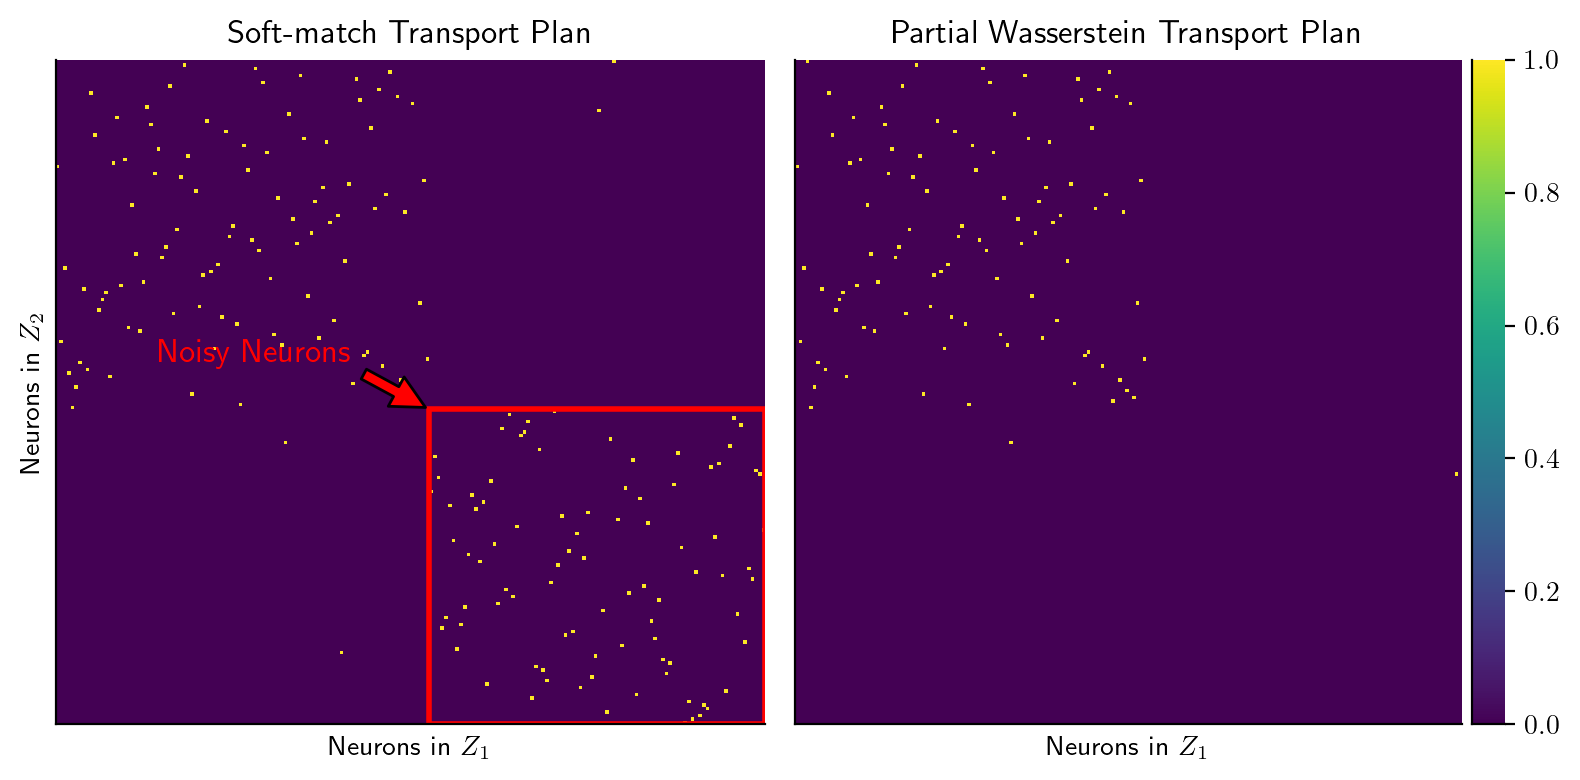

In [39]:
viz1 = sm.transform
if viz1.sum() > 0:
    viz1 = viz1 / viz1.max()

viz2 = unbalanced_sm.transform
if viz2.sum() > 0:
    viz2 = viz2 / viz2.max()

# define the region corresponding to noisy neurons
n_rows, n_cols = viz1.shape
noisy_region_rows = 90
noisy_region_cols = 90

# create figure and subplots with gridspec to control width ratios
fig, axes = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={"width_ratios": [1, 1]})

# soft-match transport plan
ax1 = sns.heatmap(viz1, cmap='viridis', cbar=False, ax=axes[0])
axes[0].set_xlabel(r'Neurons in $Z_1$')
axes[0].set_ylabel(r'Neurons in $Z_2$')
axes[0].set_title(r'Soft-match Transport Plan')
axes[0].set_xticks([])
axes[0].set_yticks([])

# add a red rectangle to highlight noisy neurons
if n_rows >= noisy_region_rows and n_cols >= noisy_region_cols:
    rect = patches.Rectangle((n_cols - noisy_region_cols, n_rows - noisy_region_rows),
                             noisy_region_cols, noisy_region_rows,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)

    # annotate the rectangle
    axes[0].annotate("Noisy Neurons", 
                     xy=(n_cols - noisy_region_cols, n_rows - noisy_region_rows),
                     xycoords='data',
                     xytext=(n_cols - noisy_region_cols - 20, n_rows - noisy_region_rows - 20),
                     textcoords='data',
                     arrowprops=dict(facecolor='red', shrink=0.05),
                     horizontalalignment='right', verticalalignment='top',
                     fontsize=12, color='red')

# unbalanced transport plan
# this is me being super nitpicky about how i want the 
# plot aspect ratios to be exactly balanced
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.05)  # create space for the colorbar

ax2 = sns.heatmap(viz2, cmap='viridis', cbar=True, ax=axes[1], cbar_ax=cax)  # assign colorbar to cax
axes[1].set_xlabel(r'Neurons in $Z_1$')
axes[1].set_title(r'Partial Wasserstein Transport Plan')
axes[1].set_xticks([])
axes[1].set_yticks([])

sns.despine(trim=True)
plt.tight_layout()
#plt.savefig('transport-plan-simulation.png', dpi=300)
plt.show()


# brute force deletion of neurons

In [80]:
device = torch.device('cuda:1')

original_rep = torch.as_tensor(z1_noisy, device=device)   
z2_tensor = torch.as_tensor(z2_noisy, device=device)   

score_history = []
# append original score without deletion
score_history.append(mean_sm)

removal_order = []
remaining = list(range(original_rep.shape[1]))

for step in tqdm(range(len(remaining) - 1), desc="Greedy pruning"):
    last_score = score_history[-1]
    best_delta = -float("inf")
    best_idx   = None
    best_score = None

    # remove each remaining neuron in turn
    for i, orig_idx in enumerate(remaining):
        # build candidate by excluding column i
        # torch.cat is more efficient than indexing lists of ints
        if i == 0:
            candidate = original_rep[:, 1:]
        elif i == original_rep.shape[1] - 1:
            candidate = original_rep[:, :-1]
        else:
            candidate = torch.cat([
                original_rep[:, :i],
                original_rep[:, i+1:]
            ], dim=1)

        # compute new soft‑match score
        scores = torch.tensor(sm.fit_kfold_score(candidate, z2_tensor))       
        new_score = torch.mean(scores)
        delta     = (new_score - last_score).item()

        # least change in score => least matched neurons
        if delta > best_delta:
            best_delta = delta
            best_idx   = i
            best_score = new_score.item()

    # commit the best deletion
    removal_order.append(remaining.pop(best_idx))

    # remove that column permanently
    if best_idx == 0:
        original_rep = original_rep[:, 1:]
    elif best_idx == original_rep.shape[1] - 1:
        original_rep = original_rep[:, :-1]
    else:
        original_rep = torch.cat([
            original_rep[:, :best_idx],
            original_rep[:, best_idx+1:]
        ], dim=1)

    score_history.append(best_score)
    tqdm.write(f"Step {step+1}: removed neuron {removal_order[-1]}, delta score={best_delta:.4f}")

Greedy pruning:   1%|▉                                                                                                                                                                                      | 1/189 [00:29<1:32:07, 29.40s/it]

Step 1: removed neuron 116, delta score=0.0013


Greedy pruning:   1%|█▉                                                                                                                                                                                     | 2/189 [01:01<1:36:03, 30.82s/it]

Step 2: removed neuron 163, delta score=0.0012


Greedy pruning:   2%|██▉                                                                                                                                                                                    | 3/189 [01:29<1:31:24, 29.49s/it]

...

Step 184: removed neuron 33, delta score=-0.0130
Step 185: removed neuron 72, delta score=-0.0154


Greedy pruning:  99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████ | 188/189 [18:06<00:00,  7.36it/s]

Step 186: removed neuron 49, delta score=-0.0154
Step 187: removed neuron 9, delta score=-0.0178
Step 188: removed neuron 99, delta score=-0.0234


Greedy pruning: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 189/189 [18:06<00:00,  5.75s/it]

Step 189: removed neuron 93, delta score=-0.0416


In [97]:
threshold = 1e-4
unmatched_units_row = torch.where(unbalanced_sm.transform.sum(axis=1) < threshold)[0]
unmatched_units_col = torch.where(unbalanced_sm.transform.sum(axis=0) < threshold)[0]

In [100]:
sum(unmatched_units_row > 99), sum(unmatched_units_col > 99)

(tensor(88), tensor(89))

In [98]:
print(unmatched_units_row, unmatched_units_col)
print(len(unmatched_units_row), len(unmatched_units_col))

tensor([ 14,  89, 100, 101, 102, 103, 104, 105, 106, 107, 108, 110, 111, 112,
        113, 114, 115, 116, 117, 119, 120, 121, 122, 123, 124, 125, 126, 127,
        128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
        142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
        170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183,
        184, 185, 186, 187, 188, 189]) tensor([ 76, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
        113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
        127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140,
        141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
        155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182,
        183, 184, 185, 18

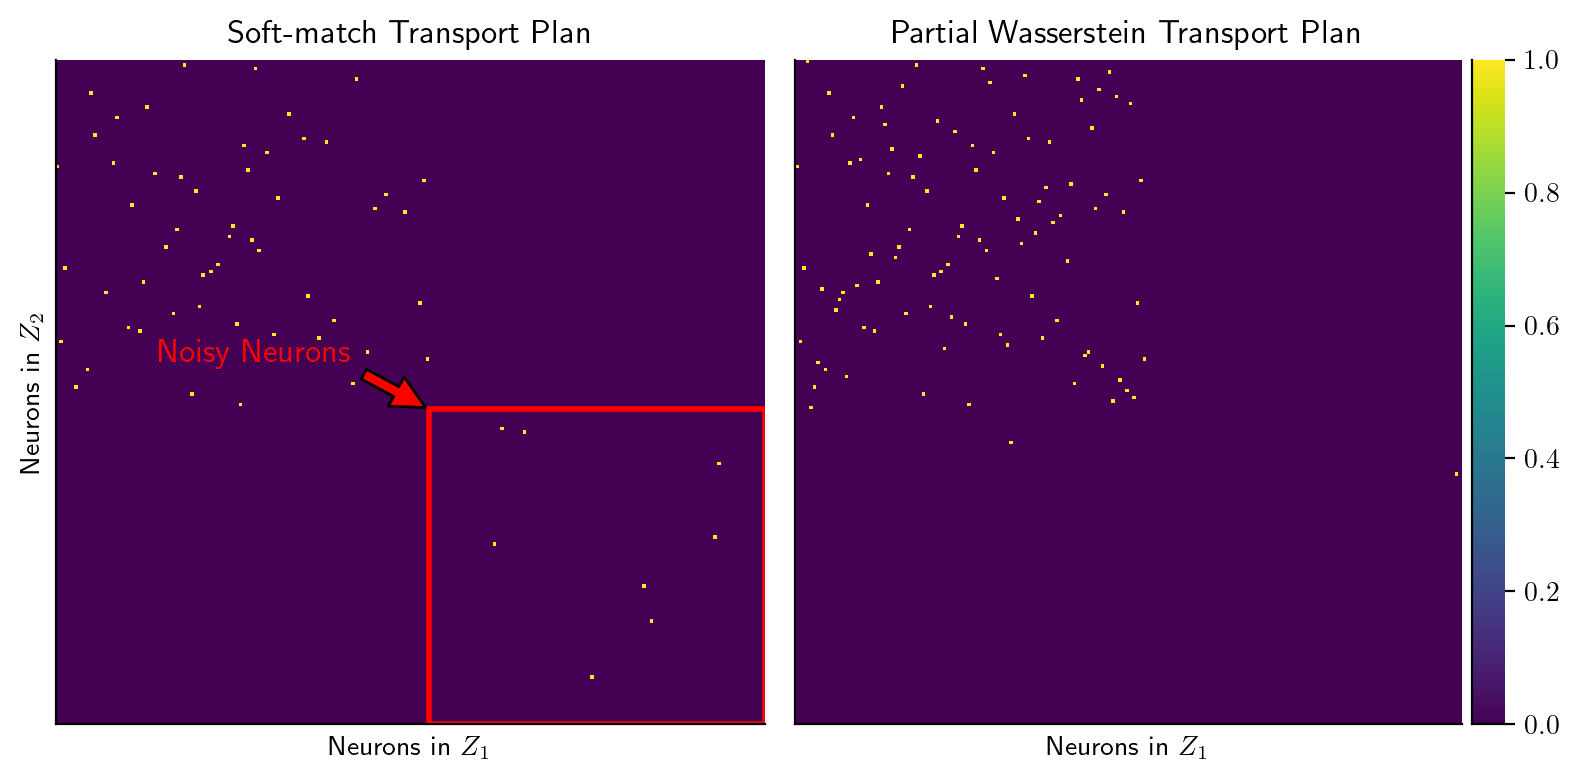

In [92]:
# now, zero out the said indices from the transport plan
# zero out brute force matched indices in soft-matching
augmented_sm_transform = sm.transform.cpu().detach().clone()
neuron_idx = removal_order[:90]
augmented_sm_transform[neuron_idx,:] = 0
augmented_sm_transform[:,neuron_idx] = 0

viz1 = augmented_sm_transform
if viz1.sum() > 0:
    viz1 = viz1 / viz1.max()

viz2 = unbalanced_sm.transform
if viz2.sum() > 0:
    viz2 = viz2 / viz2.max()


# define the region corresponding to noisy neurons
n_rows, n_cols = viz1.shape
noisy_region_rows = 90
noisy_region_cols = 90

# create figure and subplots with gridspec to control width ratios
fig, axes = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={"width_ratios": [1, 1]})

# soft-match transport plan
ax1 = sns.heatmap(viz1, cmap='viridis', cbar=False, ax=axes[0])
axes[0].set_xlabel(r'Neurons in $Z_1$')
axes[0].set_ylabel(r'Neurons in $Z_2$')
axes[0].set_title(r'Soft-match Transport Plan')
axes[0].set_xticks([])
axes[0].set_yticks([])

# add a red rectangle to highlight noisy neurons
if n_rows >= noisy_region_rows and n_cols >= noisy_region_cols:
    rect = patches.Rectangle((n_cols - noisy_region_cols, n_rows - noisy_region_rows),
                             noisy_region_cols, noisy_region_rows,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)

    # annotate the rectangle
    axes[0].annotate("Noisy Neurons", 
                     xy=(n_cols - noisy_region_cols, n_rows - noisy_region_rows),
                     xycoords='data',
                     xytext=(n_cols - noisy_region_cols - 20, n_rows - noisy_region_rows - 20),
                     textcoords='data',
                     arrowprops=dict(facecolor='red', shrink=0.05),
                     horizontalalignment='right', verticalalignment='top',
                     fontsize=12, color='red')

# unbalanced transport plan
# this is me being super nitpicky about how i want the 
# plot aspect ratios to be exactly balanced
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.05)  # create space for the colorbar

ax2 = sns.heatmap(viz2, cmap='viridis', cbar=True, ax=axes[1], cbar_ax=cax)  # assign colorbar to cax
axes[1].set_xlabel(r'Neurons in $Z_1$')
axes[1].set_title(r'Partial Wasserstein Transport Plan')
axes[1].set_xticks([])
axes[1].set_yticks([])

sns.despine(trim=True)
plt.tight_layout()
#plt.savefig('transport-plan-simulation.png', dpi=300)
plt.show()
